# E-Commerce Data Pipeline Analysis

This notebook explores the e-commerce dataset before and after cleaning.

## Objectives
- Inspect the raw dataset
- Compare raw and cleaned data
- Analyze revenue by country, product, and month
- Summarize key business insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

## 1. Raw Data Inspection
The following cells show the structure of the original dataset before cleaning.

In [23]:
raw = pd.read_csv("../data/raw/ecommerce_data.csv", encoding="ISO-8859-1")

In [6]:
raw.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-10 8:26,3.39,17850.0,United Kingdom


Shape RAW

In [7]:
print("RAW shape:", raw.shape)

RAW shape: (541909, 8)


Missing values RAW

In [8]:
raw.isnull().sum()

ï»¿InvoiceNo         0
StockCode            0
Description       1454
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      135080
Country              0
dtype: int64

## Observations on Raw Data

- The dataset contains missing values
- Some rows may include invalid or incomplete data
- Data needs cleaning before analysis

## 2. Cleaned Data Inspection
The cleaned dataset contains only valid rows used for analysis.

In [25]:
cleaned = pd.read_csv("../data/processed/cleaned_data.csv", parse_dates=["InvoiceDate"])

In [10]:
cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34


Shape CLEANED

In [11]:
print("CLEANED shape:", cleaned.shape)

CLEANED shape: (392692, 9)


Missing CLEANED

In [12]:
cleaned.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

## After Cleaning

- Missing values have been removed
- Invalid rows have been filtered
- A new column "Revenue" has been created

## 3. Before vs After Cleaning
This comparison shows how the dataset changed after removing duplicates, missing values, and invalid rows.

In [13]:
comparison = pd.DataFrame({
    "Dataset": ["Raw", "Cleaned"],
    "Rows": [raw.shape[0], cleaned.shape[0]],
    "Columns": [raw.shape[1], cleaned.shape[1]]
})
comparison

,Dataset,Rows,Columns
0,Raw,541909,8
1,Cleaned,392692,9


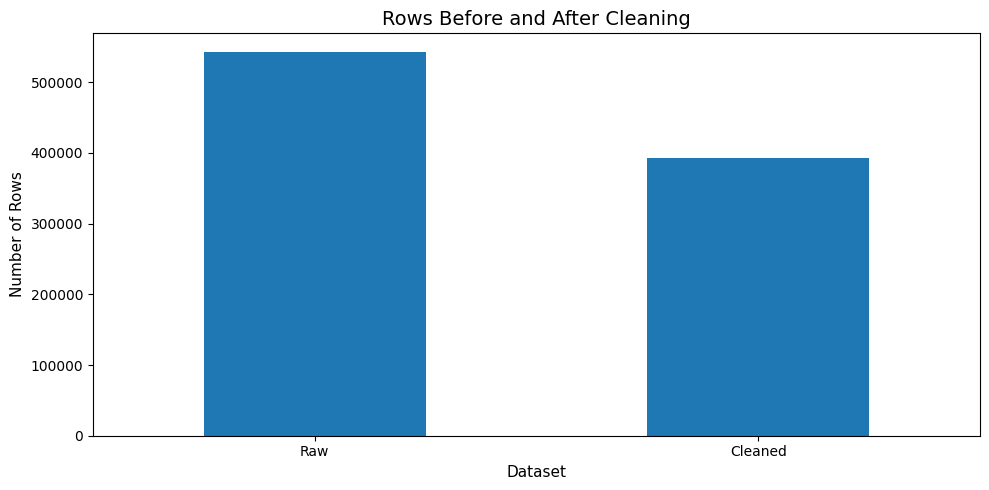

In [14]:
comparison.set_index("Dataset")["Rows"].plot(kind="bar")
plt.title("Rows Before and After Cleaning")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Revenue by Country
The chart below highlights the top countries by total revenue.

In [15]:
top_countries = (
    cleaned.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

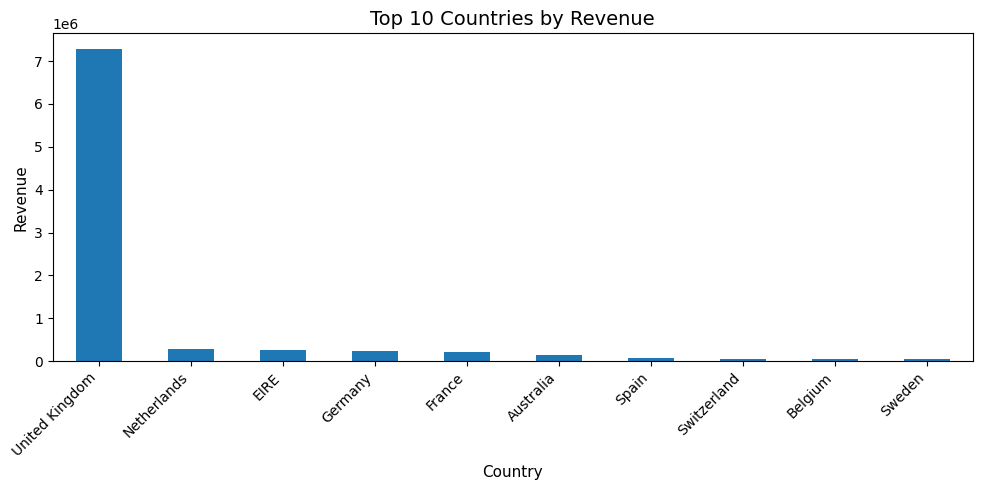

In [16]:
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Top Products by Revenue
This section shows the highest-performing products in terms of revenue.

In [17]:
top_products = (
    cleaned.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

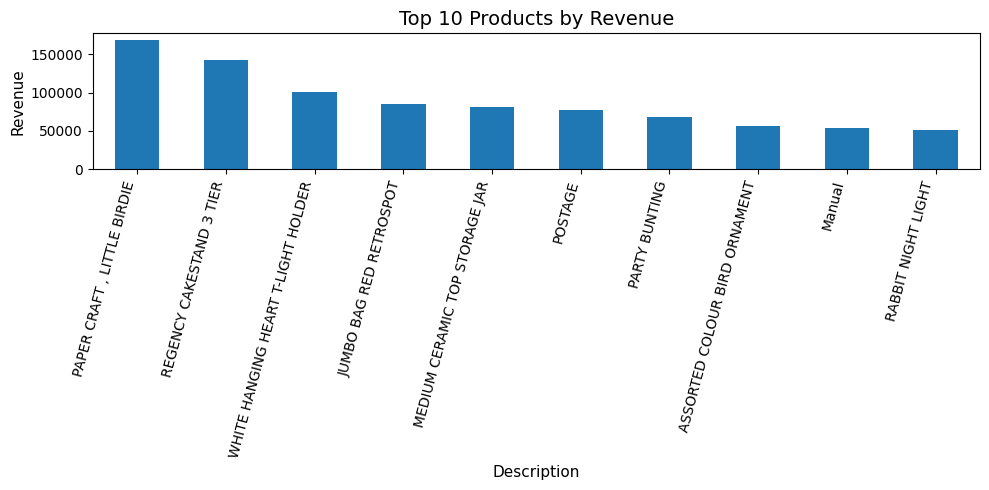

In [18]:
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

## 6. Monthly Revenue Trend
The following chart shows how revenue changed over time.

In [19]:
cleaned["InvoiceDate"] = pd.to_datetime(cleaned["InvoiceDate"])

cleaned["Month"] = cleaned["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = (
    cleaned.groupby("Month")["Revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

Month
2010-01      46192.490
2010-02      47197.570
2010-03      23876.630
2010-05      31361.280
2010-06      31009.330
2010-07      53730.960
2010-08      39094.200
2010-09      38193.910
2010-10      33488.380
2010-12     226277.980
2011-01     600330.010
2011-02     485607.660
2011-03     644633.570
2011-04     601577.861
2011-05     717482.900
2011-06     687078.540
2011-07     733983.181
2011-08     607009.590
2011-09    1093319.702
2011-10     901925.950
2011-11    1039157.810
2011-12     204679.390
Name: Revenue, dtype: float64

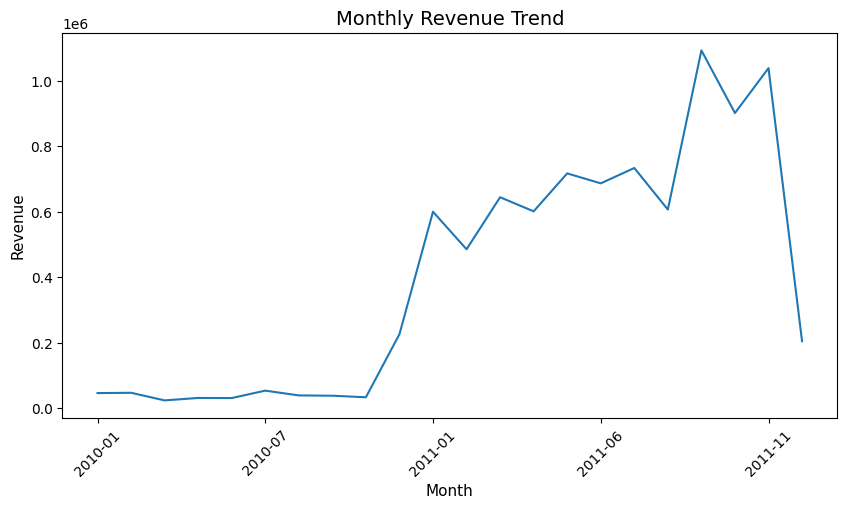

In [20]:
monthly_revenue.plot(kind="line")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


## 7. Revenue Summary
Basic descriptive statistics for the revenue column.

In [21]:
cleaned["Revenue"].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

## 8. Key Insights

- The cleaned dataset is significantly smaller than the raw dataset due to the removal of duplicates, missing values, and invalid records.
- The United Kingdom contributes the highest share of revenue.
- A small number of products account for a large portion of sales.
- Revenue changes noticeably across months, indicating seasonal or time-based trends.